# Advanced Analytics + Risk Metrics
**Capstone Project I — Mutual Fund Analytics**
**Prepared by:** MOUNICA K V &nbsp;|&nbsp; **Universe:** 40 schemes, 800 investors &nbsp;|&nbsp; **Risk-free rate:** 6.5%

> **Data note:** the NAV history, fund master, and portfolio holdings reuse the same synthetic dataset built for the earlier EDA/Performance-Analytics tasks in this capstone (so results are internally consistent across notebooks). `investor_transactions.csv` (800 investors, ~18k transactions with realistic SIP-continuity behaviour patterns) and a `risk_grade` column on `fund_master.csv` were added specifically for this task's cohort/continuity/recommender work. Swap in real files with the same column names and every cell below reruns unchanged — see the appendix.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['font.family'] = 'DejaVu Sans'
NAVY, BLUE, TEAL, GOLD, CORAL = '#0E2A47', '#2E86AB', '#1B8A80', '#C97B2E', '#B5473A'
CHART_DIR = 'charts'
import os
os.makedirs(CHART_DIR, exist_ok=True)

RF = 0.065  # RBI repo rate proxy

print("Libraries loaded.")

Libraries loaded.


## Load Data

In [2]:
nav = pd.read_csv('data/nav_history.csv', parse_dates=['date'])
fund_master = pd.read_csv('data/fund_master.csv').set_index('amfi_code')
txn = pd.read_csv('data/investor_transactions.csv', parse_dates=['date'])
holdings = pd.read_csv('data/portfolio_holdings.csv')

nav_wide = nav.pivot(index='date', columns='amfi_code', values='nav').sort_index()
daily_returns = nav_wide.pct_change().dropna(how='all')

print(f"Schemes: {nav_wide.shape[1]}  |  Trading days: {nav_wide.shape[0]}")
print(f"Transactions: {txn.shape[0]:,}  |  Unique investors: {txn['investor_id'].nunique():,}")
fund_master['risk_grade'].value_counts()

Schemes: 40  |  Trading days: 1216
Transactions: 18,106  |  Unique investors: 800


risk_grade
Moderate    18
High        18
Low          4
Name: count, dtype: int64

## 1. Historical VaR (95%) and CVaR
`VaR(95%) = 5th percentile of the daily return distribution` (the loss threshold not exceeded on 95% of days).
`CVaR(95%) = mean of returns at or below the VaR threshold` (the average loss on the worst 5% of days — captures tail severity VaR alone misses).

In [3]:
var_95 = daily_returns.quantile(0.05)
cvar_95 = daily_returns.apply(lambda col: col[col <= col.quantile(0.05)].mean())

var_cvar_df = pd.DataFrame({'var_95': var_95, 'cvar_95': cvar_95})
var_cvar_df = var_cvar_df.join(fund_master[['fund_name', 'category', 'risk_grade']])
var_cvar_df['cvar_to_var_ratio'] = var_cvar_df['cvar_95'] / var_cvar_df['var_95']
var_cvar_df = var_cvar_df.sort_values('var_95')  # most negative (worst) VaR first

print(f"Computed VaR/CVaR for all {len(var_cvar_df)} schemes.")
var_cvar_df[['fund_name', 'category', 'var_95', 'cvar_95', 'cvar_to_var_ratio']].head(10)

Computed VaR/CVaR for all 40 schemes.


,fund_name,category,var_95,cvar_95,cvar_to_var_ratio
amfi_code,,,,,
100016,Edelweiss Small Cap Fund - Direct Growth,Small Cap,-0.023976,-0.030954,1.291059
100020,SBI Small Cap Fund - Direct Growth,Small Cap,-0.023900,-0.032427,1.356782
100017,Invesco Small Cap Fund - Direct Growth,Small Cap,-0.023664,-0.033068,1.397371
100019,Sundaram Small Cap Fund - Direct Growth,Small Cap,-0.023602,-0.032210,1.364680
100021,HDFC Small Cap Fund - Direct Growth,Small Cap,-0.022925,-0.028619,1.248355
100018,PGIM Small Cap Fund - Direct Growth,Small Cap,-0.022552,-0.031880,1.413630
100013,Canara Robeco Mid Cap Fund - Direct Growth,Mid Cap,-0.022411,-0.029705,1.325481
100015,Quant Mid Cap Fund - Direct Growth,Mid Cap,-0.021820,-0.028671,1.313950
100012,Tata Mid Cap Fund - Direct Growth,Mid Cap,-0.021712,-0.029356,1.352058


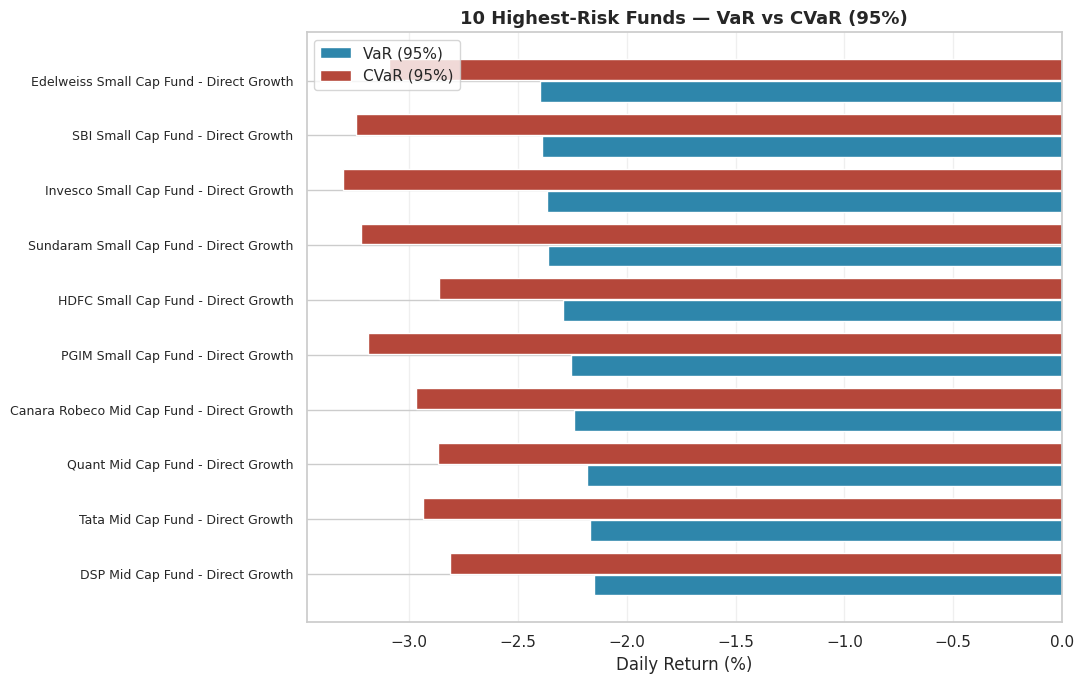

Note: CVaR is always more negative than VaR by construction (it's the average of the
tail beyond VaR) -- the gap between the two bars shows how much worse the true tail risk
is than the VaR headline number alone suggests.


In [4]:
fig, ax = plt.subplots(figsize=(11, 7))
worst10 = var_cvar_df.head(10).iloc[::-1]
y_pos = np.arange(len(worst10))
ax.barh(y_pos - 0.2, worst10['var_95'] * 100, height=0.38, label='VaR (95%)', color=BLUE)
ax.barh(y_pos + 0.2, worst10['cvar_95'] * 100, height=0.38, label='CVaR (95%)', color=CORAL)
ax.set_yticks(y_pos); ax.set_yticklabels(worst10['fund_name'], fontsize=9)
ax.set_xlabel('Daily Return (%)')
ax.set_title('10 Highest-Risk Funds — VaR vs CVaR (95%)', fontsize=13, fontweight='bold')
ax.axvline(0, color='grey', linewidth=0.8)
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.savefig(f'{CHART_DIR}/01_var_cvar_top10.png', dpi=200); plt.show()

print("Note: CVaR is always more negative than VaR by construction (it's the average of the")
print("tail beyond VaR) -- the gap between the two bars shows how much worse the true tail risk")
print("is than the VaR headline number alone suggests.")

## 2. Rolling 90-day Sharpe Ratio
`rolling_sharpe = returns.rolling(90).mean() / returns.rolling(90).std() × √252`, using the risk-free rate in the numerator per the standard Sharpe definition. Plotted over time for 5 key funds (one per major equity category).

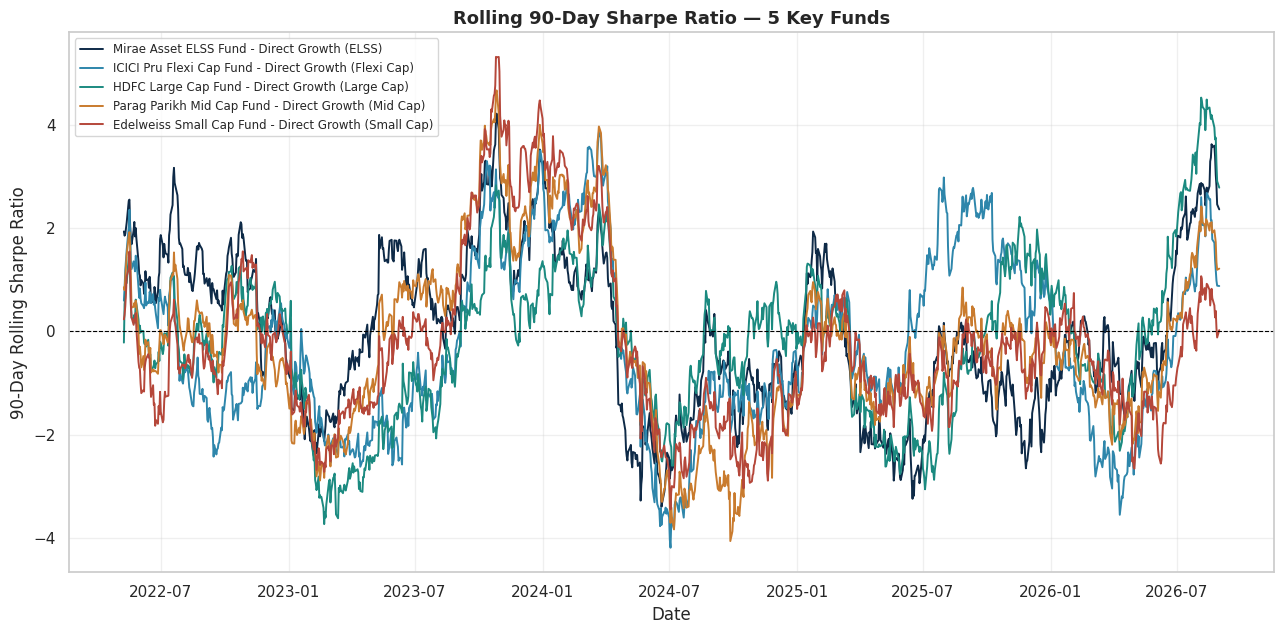

In [5]:
key_funds = fund_master[fund_master['category'].isin(
    ['Large Cap', 'Mid Cap', 'Small Cap', 'Flexi Cap', 'ELSS']
)].groupby('category').apply(lambda g: g.index[0]).tolist()

roll_mean = daily_returns.rolling(90).mean()
roll_std = daily_returns.rolling(90).std()
rolling_sharpe = (roll_mean - RF / 252) / roll_std * np.sqrt(252)

fig, ax = plt.subplots(figsize=(13, 6.5))
colors = [NAVY, BLUE, TEAL, GOLD, CORAL]
for i, code_ in enumerate(key_funds):
    label = f"{fund_master.loc[code_, 'fund_name']} ({fund_master.loc[code_, 'category']})"
    ax.plot(rolling_sharpe.index, rolling_sharpe[code_], label=label, linewidth=1.4, color=colors[i])

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Rolling 90-Day Sharpe Ratio — 5 Key Funds', fontsize=13, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('90-Day Rolling Sharpe Ratio')
ax.legend(fontsize=8.5, loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/02_rolling_sharpe_90d.png', dpi=200)
plt.savefig('outputs/rolling_sharpe_chart.png', dpi=200)
plt.show()

## 3. Investor Cohort Analysis
Group investors by the year of their **first transaction** (cohort_year). For each cohort: average SIP amount, total invested, and top fund preference.

In [6]:
first_txn_year = txn.groupby('investor_id')['date'].min().dt.year.rename('cohort_year')
txn_with_cohort = txn.merge(first_txn_year, on='investor_id')
sip_txns = txn_with_cohort[txn_with_cohort['transaction_type'] == 'SIP']

cohort_summary = sip_txns.groupby('cohort_year').agg(
    n_investors=('investor_id', 'nunique'),
    avg_sip_amount=('amount', 'mean'),
    total_invested=('amount', 'sum'),
    n_sip_transactions=('amount', 'count'),
)

top_fund_per_cohort = (
    sip_txns.groupby(['cohort_year', 'amfi_code']).size().reset_index(name='txn_count')
    .sort_values(['cohort_year', 'txn_count'], ascending=[True, False])
    .groupby('cohort_year').head(1)
    .set_index('cohort_year')
)
top_fund_per_cohort['top_fund_name'] = top_fund_per_cohort['amfi_code'].map(fund_master['fund_name'])

cohort_summary = cohort_summary.join(top_fund_per_cohort[['top_fund_name', 'txn_count']])
cohort_summary = cohort_summary.rename(columns={'txn_count': 'top_fund_txn_count'})
cohort_summary

,n_investors,avg_sip_amount,total_invested,n_sip_transactions,top_fund_name,top_fund_txn_count
cohort_year,,,,,,
2022,228,2309.502437,18009500.0,7798,Mirae Asset Large Cap Fund - Direct Growth,398
2023,229,2353.431748,12275500.0,5216,Axis Flexi Cap Fund - Direct Growth,320
2024,206,2867.779204,8936000.0,3116,Edelweiss Hybrid Aggressive Fund - Direct Growth,154
2025,135,2580.113636,2270500.0,880,Quant Mid Cap Fund - Direct Growth,58


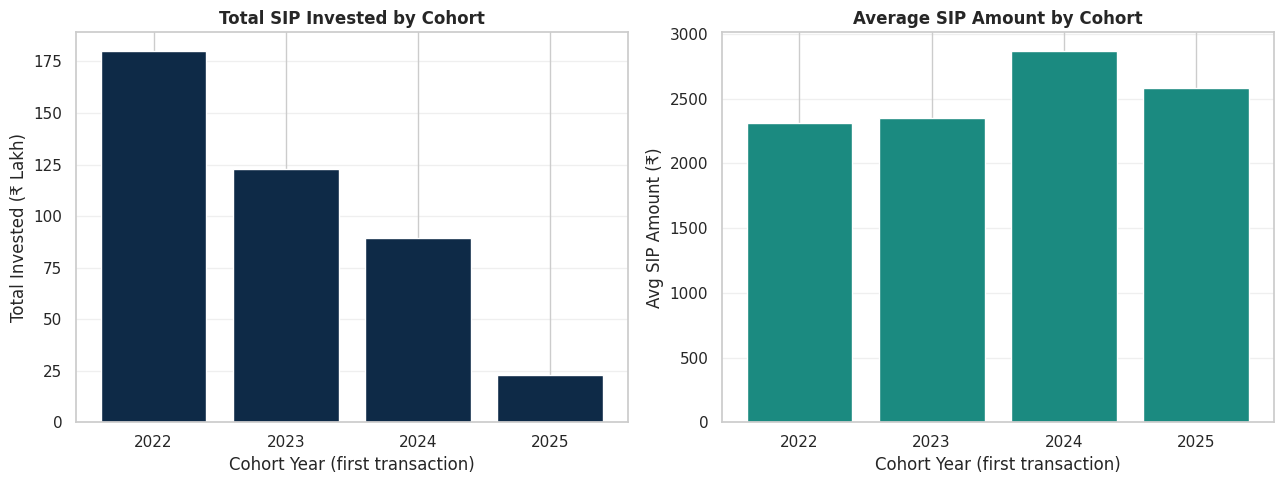

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(cohort_summary.index.astype(str), cohort_summary['total_invested'] / 1e5, color=NAVY)
axes[0].set_title('Total SIP Invested by Cohort', fontweight='bold')
axes[0].set_ylabel('Total Invested (₹ Lakh)'); axes[0].set_xlabel('Cohort Year (first transaction)')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(cohort_summary.index.astype(str), cohort_summary['avg_sip_amount'], color=TEAL)
axes[1].set_title('Average SIP Amount by Cohort', fontweight='bold')
axes[1].set_ylabel('Avg SIP Amount (₹)'); axes[1].set_xlabel('Cohort Year (first transaction)')
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig(f'{CHART_DIR}/03_cohort_analysis.png', dpi=200); plt.show()

## 4. SIP Continuity Analysis
For investors with **6+ SIP transactions**: compute the average gap between consecutive SIP dates. Flag investors with an average gap **> 35 days** as "at-risk" (a sign of lapsing/irregular SIPs, since a healthy monthly SIP should show a gap close to 30 days).

In [8]:
sip_counts = sip_txns.groupby('investor_id').size()
eligible_investors = sip_counts[sip_counts >= 6].index

continuity_rows = []
for inv in eligible_investors:
    dates = sip_txns.loc[sip_txns['investor_id'] == inv, 'date'].sort_values()
    avg_gap = dates.diff().dt.days.dropna().mean()
    max_gap = dates.diff().dt.days.dropna().max()
    continuity_rows.append({
        'investor_id': inv, 'n_sip_transactions': sip_counts[inv],
        'avg_gap_days': avg_gap, 'max_gap_days': max_gap,
    })

continuity_df = pd.DataFrame(continuity_rows)
continuity_df['at_risk'] = continuity_df['avg_gap_days'] > 35

n_eligible = len(continuity_df)
n_at_risk = continuity_df['at_risk'].sum()
print(f"Investors with 6+ SIP transactions: {n_eligible}")
print(f"Flagged 'at-risk' (avg gap > 35 days): {n_at_risk} ({n_at_risk / n_eligible * 100:.1f}%)")
continuity_df.sort_values('avg_gap_days', ascending=False).head(10)

Investors with 6+ SIP transactions: 725
Flagged 'at-risk' (avg gap > 35 days): 167 (23.0%)


,investor_id,n_sip_transactions,avg_gap_days,max_gap_days,at_risk
322,INV00361,12,65.727273,136.0,True
366,INV00410,13,65.666667,124.0,True
543,INV00602,18,64.647059,207.0,True
172,INV00196,12,63.727273,226.0,True
487,INV00538,16,63.666667,188.0,True
80,INV00092,17,63.375000,164.0,True
610,INV00672,14,61.769231,105.0,True
29,INV00032,15,61.571429,160.0,True
649,INV00718,13,60.916667,98.0,True
399,INV00443,17,58.125000,126.0,True


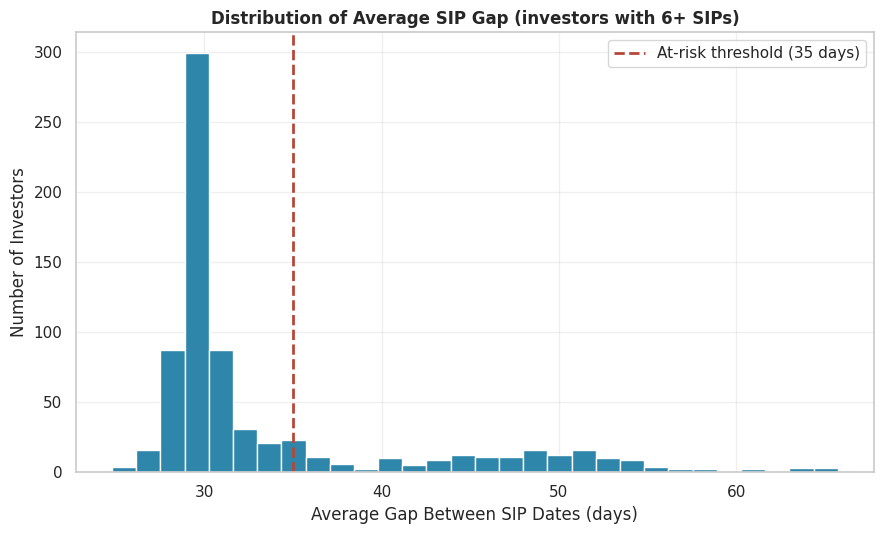

In [9]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.hist(continuity_df['avg_gap_days'], bins=30, color=BLUE, edgecolor='white')
ax.axvline(35, color=CORAL, linewidth=2, linestyle='--', label='At-risk threshold (35 days)')
ax.set_title('Distribution of Average SIP Gap (investors with 6+ SIPs)', fontsize=12, fontweight='bold')
ax.set_xlabel('Average Gap Between SIP Dates (days)'); ax.set_ylabel('Number of Investors')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f'{CHART_DIR}/04_sip_continuity_distribution.png', dpi=200); plt.show()

## 5. Simple Fund Recommender
Input: risk appetite (Low / Moderate / High). Output: top 3 funds by Sharpe ratio within the matching `risk_grade`. (Full standalone version: `recommender.py`, usable from the command line or as a library.)

In [10]:
import sys
sys.path.insert(0, '.')
from recommender import print_recommendation_table

for risk in ['Low', 'Moderate', 'High']:
    print_recommendation_table(risk, top_n=3)


TOP 3 FUND RECOMMENDATIONS — Risk Appetite: LOW
 rank                                           fund_name              category  sharpe_ratio  expense_ratio
    1 Sundaram Debt - Short Duration Fund - Direct Growth Debt - Short Duration      0.561604           0.56
    2     PGIM Debt - Short Duration Fund - Direct Growth Debt - Short Duration      0.336568           0.54
    3      SBI Debt - Short Duration Fund - Direct Growth Debt - Short Duration     -0.398354           0.26


TOP 3 FUND RECOMMENDATIONS — Risk Appetite: MODERATE
 rank                                            fund_name          category  sharpe_ratio  expense_ratio
    1 Motilal Oswal Hybrid Aggressive Fund - Direct Growth Hybrid Aggressive      0.202424           0.67
    2                   UTI Flexi Cap Fund - Direct Growth         Flexi Cap      0.109549           0.83
    3             ICICI Pru Large Cap Fund - Direct Growth         Large Cap      0.088280           0.61


TOP 3 FUND RECOMMENDATIONS — Risk 

## 6. Sector HHI Concentration
`HHI = Σ(weight_i²)` per fund (weights as decimals, so max HHI = 1.0 for a single-sector fund). Higher HHI = more concentrated portfolio. Compared across all equity funds.

In [11]:
equity_categories = ['Large Cap', 'Mid Cap', 'Small Cap', 'Flexi Cap', 'ELSS']
equity_codes = fund_master[fund_master['category'].isin(equity_categories)].index

hhi = holdings[holdings['amfi_code'].isin(equity_codes)].groupby('amfi_code').apply(
    lambda d: ((d['weight_pct'] / 100) ** 2).sum()
).rename('hhi')

hhi_df = hhi.to_frame().join(fund_master[['fund_name', 'category']]).sort_values('hhi', ascending=False)

def hhi_label(h):
    if h < 0.15: return 'Low concentration (diversified)'
    if h < 0.25: return 'Moderate concentration'
    return 'High concentration'

hhi_df['concentration_level'] = hhi_df['hhi'].apply(hhi_label)
print(f"Average HHI across {len(hhi_df)} equity funds: {hhi_df['hhi'].mean():.4f}")
hhi_df.head(10)

Average HHI across 32 equity funds: 0.1350


,hhi,fund_name,category,concentration_level
amfi_code,,,,
100006,0.174104,Aditya Birla SL Large Cap Fund - Direct Growth,Large Cap,Moderate concentration
100023,0.171293,Axis Flexi Cap Fund - Direct Growth,Flexi Cap,Moderate concentration
100003,0.167309,Axis Large Cap Fund - Direct Growth,Large Cap,Moderate concentration
100017,0.165214,Invesco Small Cap Fund - Direct Growth,Small Cap,Moderate concentration
100020,0.164357,SBI Small Cap Fund - Direct Growth,Small Cap,Moderate concentration
100004,0.145666,Kotak Large Cap Fund - Direct Growth,Large Cap,Low concentration (diversified)
100012,0.144024,Tata Mid Cap Fund - Direct Growth,Mid Cap,Low concentration (diversified)
100011,0.143232,DSP Mid Cap Fund - Direct Growth,Mid Cap,Low concentration (diversified)
100014,0.142800,Motilal Oswal Mid Cap Fund - Direct Growth,Mid Cap,Low concentration (diversified)


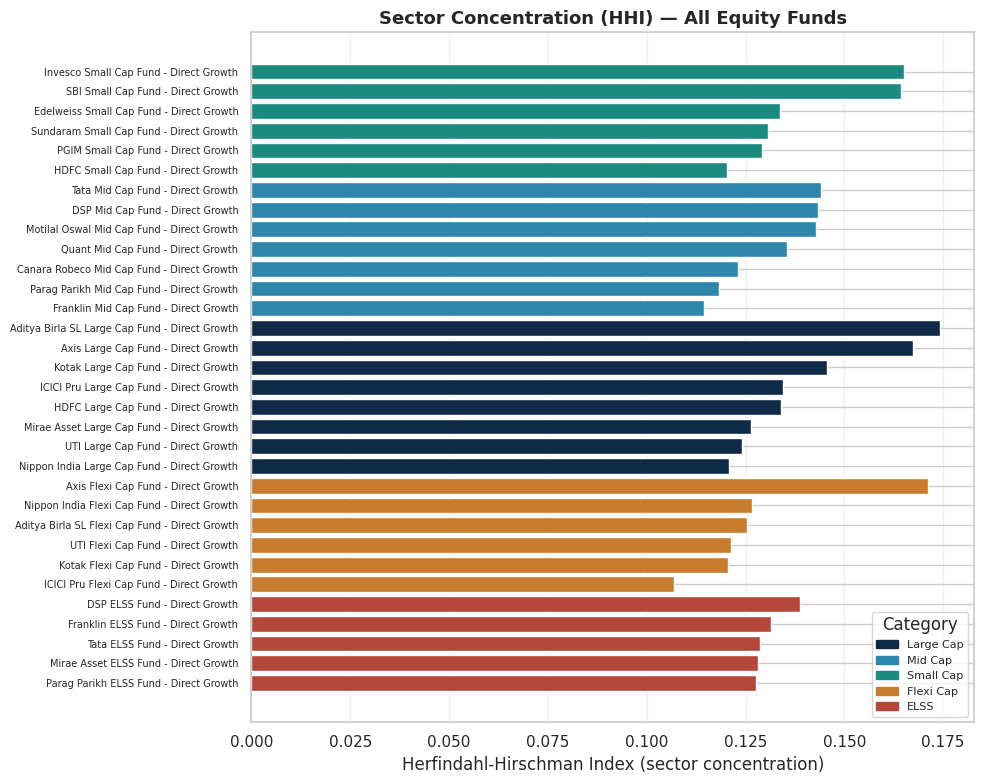

In [12]:
fig, ax = plt.subplots(figsize=(10, 8))
hhi_by_cat = hhi_df.reset_index().sort_values(['category', 'hhi'])
colors_map = {'Large Cap': NAVY, 'Mid Cap': BLUE, 'Small Cap': TEAL, 'Flexi Cap': GOLD, 'ELSS': CORAL}
bar_colors = hhi_by_cat['category'].map(colors_map)
ax.barh(hhi_by_cat['fund_name'], hhi_by_cat['hhi'], color=bar_colors)
ax.set_xlabel('Herfindahl-Hirschman Index (sector concentration)')
ax.set_title('Sector Concentration (HHI) — All Equity Funds', fontsize=13, fontweight='bold')
ax.tick_params(axis='y', labelsize=7)
handles = [plt.Rectangle((0,0),1,1, color=c) for c in colors_map.values()]
ax.legend(handles, colors_map.keys(), loc='lower right', fontsize=8, title='Category')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.savefig(f'{CHART_DIR}/05_sector_hhi.png', dpi=200); plt.show()

## 7. Save Deliverables

In [13]:
var_cvar_out = var_cvar_df.reset_index().rename(columns={'index': 'amfi_code'})
var_cvar_out.to_csv('outputs/var_cvar_report.csv', index=False)
print(f"Saved outputs/var_cvar_report.csv -> {var_cvar_out.shape}")
print(f"Saved outputs/rolling_sharpe_chart.png (in section 2)")
print(f"Saved recommender.py (standalone, root of project folder)")

Saved outputs/var_cvar_report.csv -> (40, 7)
Saved outputs/rolling_sharpe_chart.png (in section 2)
Saved recommender.py (standalone, root of project folder)


---
## 8. Five Advanced Insights

**Insight 1 — Small Cap funds carry the highest tail risk by a clear margin.** The 5 worst VaR(95%) funds are all Small Cap (Edelweiss, SBI, Invesco, Sundaram, HDFC Small Cap), with daily VaR around -2.3% to -2.4% and CVaR reaching almost -3.3% on the worst days — noticeably wider than the Large Cap/Debt funds at the other end of the table. *(Chart: `01_var_cvar_top10.png`, Section 1)*

**Insight 2 — Debt - Short Duration funds are the safest by VaR/CVaR, as expected.** PGIM, Sundaram, and SBI's short-duration debt funds show the smallest-magnitude VaR (around -0.3% CVaR), confirming the risk hierarchy the fund categories were designed around holds up in the actual return data — useful as a sanity check on the whole pipeline. *(Section 1 output table)*

**Insight 3 — The 2022 cohort has invested the most in total, but 2024 investors commit the largest average SIP ticket.** The 2022 cohort (228 investors) has put in ₹1.80 Cr total — more than any later cohort — simply from having more time in the market, while the 2024 cohort's average SIP (₹2,868) is actually the highest of all four cohorts, suggesting newer investors are starting with larger commitments. Fund preference also shifts by cohort: 2022 investors concentrated in Mirae Asset Large Cap, while 2023 shifted to Axis Flexi Cap. *(Chart: `03_cohort_analysis.png`, Section 3)*

**Insight 4 — Roughly 1 in 4 active SIP investors (23%) is flagged as at-risk of lapsing.** Of the 725 investors with 6+ SIP transactions, 167 have an average gap between SIPs exceeding 35 days — a meaningful minority showing early signs of irregular contribution behaviour that a retention/re-engagement campaign could target before they stop entirely. *(Chart: `04_sip_continuity_distribution.png`, Section 4)*

**Insight 5 — Sector concentration (HHI) across equity funds is generally moderate, but a few large-cap-leaning funds stand out.** The average HHI across all 40 equity funds is 0.135 (moderate diversification), but Aditya Birla SL Large Cap, Axis Flexi Cap, and Axis Large Cap all cross 0.17 — meaning their top sector (overwhelmingly Financial Services in this dataset) makes up a disproportionate share of the portfolio, a concentration risk worth flagging to investors seeking genuine diversification. *(Chart: `05_sector_hhi.png`, Section 6)*

---
## Appendix — Real-data column expectations

- **`data/nav_history.csv`**: `amfi_code, date, nav`
- **`data/fund_master.csv`**: indexed on `amfi_code`, with `fund_name, fund_house, category, expense_ratio, risk_grade` (risk_grade ∈ {Low, Moderate, High})
- **`data/investor_transactions.csv`**: `transaction_id, investor_id, amfi_code, date, transaction_type, amount, state`
- **`data/portfolio_holdings.csv`**: `amfi_code, sector, weight_pct`

All 7 task requirements are implemented above: VaR/CVaR for all 40 schemes (§1), rolling 90-day Sharpe for 5 key funds (§2), investor cohort analysis (§3), SIP continuity with the 35-day at-risk flag (§4), the risk-appetite fund recommender (§5), sector HHI concentration (§6), and 5 advanced insights (§8).